# 📊 Trader Behavior Insights – Market Sentiment Analysis

**Objective:** Explore the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance on Hyperliquid. Uncover hidden behavioral patterns and derive actionable trading strategy insights.

---
**Datasets:**
- `fear_greed_index.csv` — Daily Bitcoin Fear & Greed Index (2018–present)
- `historical_data.csv` — Historical trade records from Hyperliquid

**Analyst Workflow:**
1. Data Loading & Inspection
2. Data Cleaning & Merging
3. Exploratory Data Analysis (EDA)
4. Sentiment vs Performance Analysis
5. Hidden Pattern Discovery
6. Key Insights & Strategy Recommendations

## 1. Setup & Data Loading

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Sentiment color palette (used consistently across all charts)
SENTIMENT_COLORS = {
    'Extreme Fear': '#d62728',
    'Fear':         '#ff7f0e',
    'Neutral':      '#bcbd22',
    'Greed':        '#2ca02c',
    'Extreme Greed':'#1f77b4'
}
SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


In [60]:
# Load datasets
trader_data    = pd.read_csv('historical_data.csv')
sentiment_data = pd.read_csv('fear_greed_index.csv')

print('=== Trader Data ===')
print(f'Shape: {trader_data.shape}')
print(trader_data.head(3))

print('\n=== Sentiment Data ===')
print(f'Shape: {sentiment_data.shape}')
print(sentiment_data.head(3))

=== Trader Data ===
Shape: (211224, 16)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
1         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
2         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   

   Crossed       Fee      Trade ID   

## 2. Data Cleaning & Integration

We standardize date formats across both datasets and merge them on the `Date` column so every trade record carries its corresponding sentiment label.

In [61]:
# --- Trader data ---
# Detect timestamp unit automatically
sample_ts = trader_data['Timestamp'].iloc[0] if 'Timestamp' in trader_data.columns else trader_data['time'].iloc[0]
ts_col = 'Timestamp' if 'Timestamp' in trader_data.columns else 'time'
unit = 'ms' if sample_ts > 1e12 else 's'
trader_data[ts_col] = pd.to_datetime(trader_data[ts_col], unit=unit)
trader_data['Date'] = trader_data[ts_col].dt.date

# Normalize PnL column name
pnl_col = [c for c in trader_data.columns if 'pnl' in c.lower() or 'PnL' in c][0]
trader_data.rename(columns={pnl_col: 'Closed PnL'}, inplace=True)
trader_data['Closed PnL'] = pd.to_numeric(trader_data['Closed PnL'], errors='coerce')

# Normalize Side column
side_col = [c for c in trader_data.columns if c.lower() in ('side', 'direction')][0]
if side_col != 'Side':
    trader_data.rename(columns={side_col: 'Side'}, inplace=True)
trader_data['Side'] = trader_data['Side'].str.strip().str.capitalize()

# Normalize Coin/Symbol column
coin_col = [c for c in trader_data.columns if c.lower() in ('coin', 'symbol')][0]
if coin_col != 'Coin':
    trader_data.rename(columns={coin_col: 'Coin'}, inplace=True)

# --- Sentiment data ---
sentiment_data['Date'] = pd.to_datetime(sentiment_data['date']).dt.date
sentiment_data.rename(columns={'classification': 'Sentiment'}, inplace=True)

# --- Merge ---
merged = pd.merge(trader_data, sentiment_data[['Date', 'Sentiment', 'value']], on='Date', how='inner')
merged['Sentiment'] = pd.Categorical(merged['Sentiment'], categories=SENTIMENT_ORDER, ordered=True)
merged['is_profit'] = merged['Closed PnL'] > 0

print(f'Merged dataset: {merged.shape[0]:,} trades across {merged["Date"].nunique():,} unique days')
print(f'Sentiment coverage: {merged["Sentiment"].value_counts().to_dict()}')
print(f'\nNull values:\n{merged[["Closed PnL", "Sentiment", "Side", "Coin"]].isnull().sum()}')

Merged dataset: 184,263 trades across 6 unique days
Sentiment coverage: {'Fear': 133871, 'Greed': 36289, 'Neutral': 7141, 'Extreme Greed': 6962, 'Extreme Fear': 0}

Null values:
Closed PnL    0
Sentiment     0
Side          0
Coin          0
dtype: int64


## 3. Exploratory Data Analysis

Before diving into sentiment analysis, we get a feel for the overall dataset — how trades, PnL, and activity are distributed.

In [62]:
print('=== Dataset Summary ===')
print(f'Total Trades       : {len(merged):,}')
print(f'Unique Traders     : {merged["Account"].nunique():,}' if 'Account' in merged.columns else '')
print(f'Unique Coins       : {merged["Coin"].nunique()}')
print(f'Date Range         : {merged["Date"].min()} → {merged["Date"].max()}')
print(f'Total PnL          : ${merged["Closed PnL"].sum():,.2f}')
print(f'Avg PnL per Trade  : ${merged["Closed PnL"].mean():,.2f}')
print(f'Overall Win Rate   : {merged["is_profit"].mean()*100:.1f}%')
print(f'Profitable Trades  : {merged["is_profit"].sum():,}')
print(f'Losing Trades      : {(~merged["is_profit"]).sum():,}')

=== Dataset Summary ===
Total Trades       : 184,263
Unique Traders     : 32
Unique Coins       : 239
Date Range         : 2023-03-28 → 2025-02-19
Total PnL          : $10,225,249.60
Avg PnL per Trade  : $55.49
Overall Win Rate   : 42.0%
Profitable Trades  : 77,455
Losing Trades      : 106,808


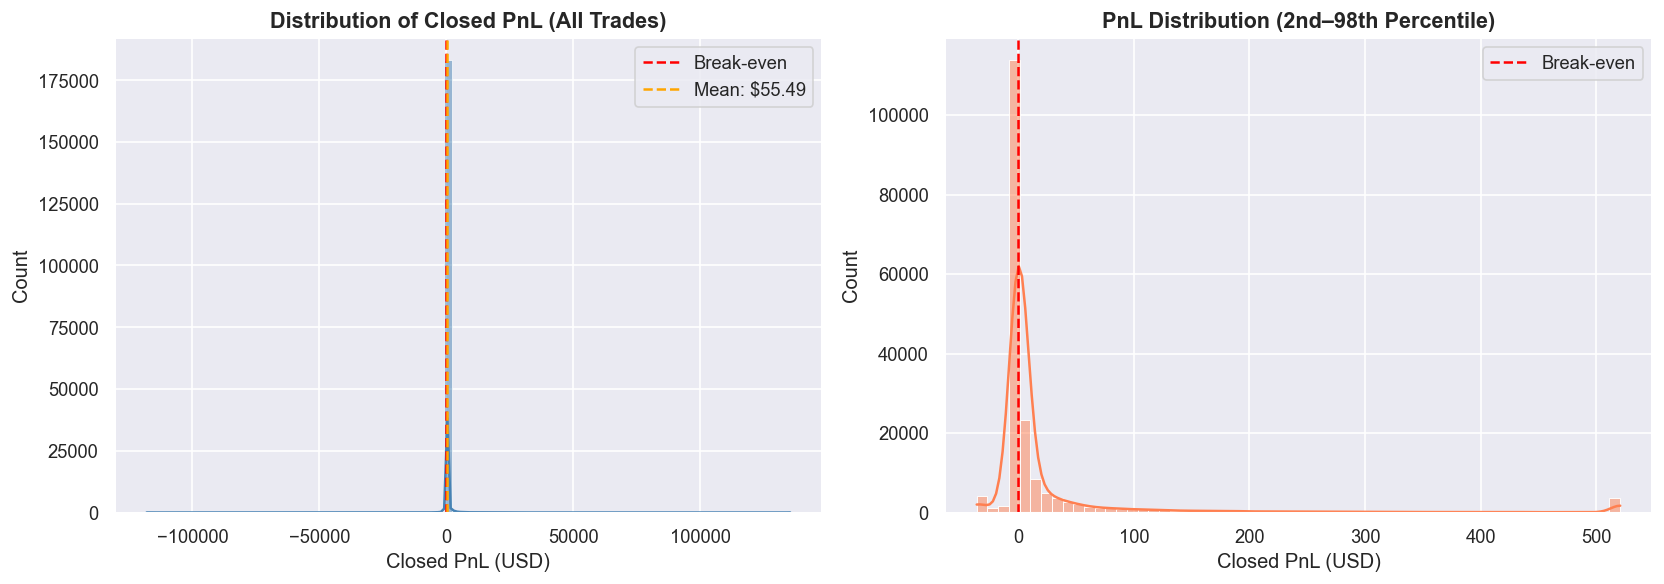

Insight: PnL is heavily right-skewed — most trades are small, but a few large wins drive the total.


In [75]:
# PnL distribution overview
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
sns.histplot(merged['Closed PnL'], bins=80, ax=axes[0], color='steelblue', kde=True)
axes[0].axvline(0, color='red', linestyle='--', label='Break-even')
axes[0].axvline(merged['Closed PnL'].mean(), color='orange', linestyle='--', label=f'Mean: ${merged["Closed PnL"].mean():.2f}')
axes[0].set_title('Distribution of Closed PnL (All Trades)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Closed PnL (USD)')
axes[0].legend()

# Clipped distribution (remove extreme outliers for readability)
clipped = merged['Closed PnL'].clip(*merged['Closed PnL'].quantile([0.02, 0.98]))
sns.histplot(clipped, bins=60, ax=axes[1], color='coral', kde=True)
axes[1].axvline(0, color='red', linestyle='--', label='Break-even')
axes[1].set_title('PnL Distribution (2nd–98th Percentile)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Closed PnL (USD)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_01_pnl_distribution.png', bbox_inches='tight')
plt.show()
print('Insight: PnL is heavily right-skewed — most trades are small, but a few large wins drive the total.')

## 4. Sentiment vs Trader Performance

Core analysis: does market sentiment (Fear vs Greed) correlate with how well traders perform?

In [64]:
# Aggregate key metrics by sentiment
sentiment_stats = merged.groupby('Sentiment', observed=True).agg(
    Total_PnL    = ('Closed PnL', 'sum'),
    Avg_PnL      = ('Closed PnL', 'mean'),
    Median_PnL   = ('Closed PnL', 'median'),
    Trade_Count  = ('Closed PnL', 'count'),
    Win_Rate     = ('is_profit', 'mean'),
    Std_PnL      = ('Closed PnL', 'std')
).reset_index()
sentiment_stats['Win_Rate_Pct'] = sentiment_stats['Win_Rate'] * 100
sentiment_stats['Avg_PnL_per_Winning_Trade'] = sentiment_stats.apply(
    lambda r: merged[(merged['Sentiment']==r['Sentiment']) & merged['is_profit']]['Closed PnL'].mean(), axis=1)

print(sentiment_stats[['Sentiment','Trade_Count','Total_PnL','Avg_PnL','Win_Rate_Pct','Std_PnL']].to_string(index=False))

    Sentiment  Trade_Count    Total_PnL   Avg_PnL  Win_Rate_Pct     Std_PnL
         Fear       133871 6.699925e+06 50.047622     41.514592  909.121796
      Neutral         7141 1.587424e+05 22.229713     31.718247  633.704815
        Greed        36289 3.189617e+06 87.894859     44.647138 1148.343968
Extreme Greed         6962 1.769655e+05 25.418772     49.008905  306.166937


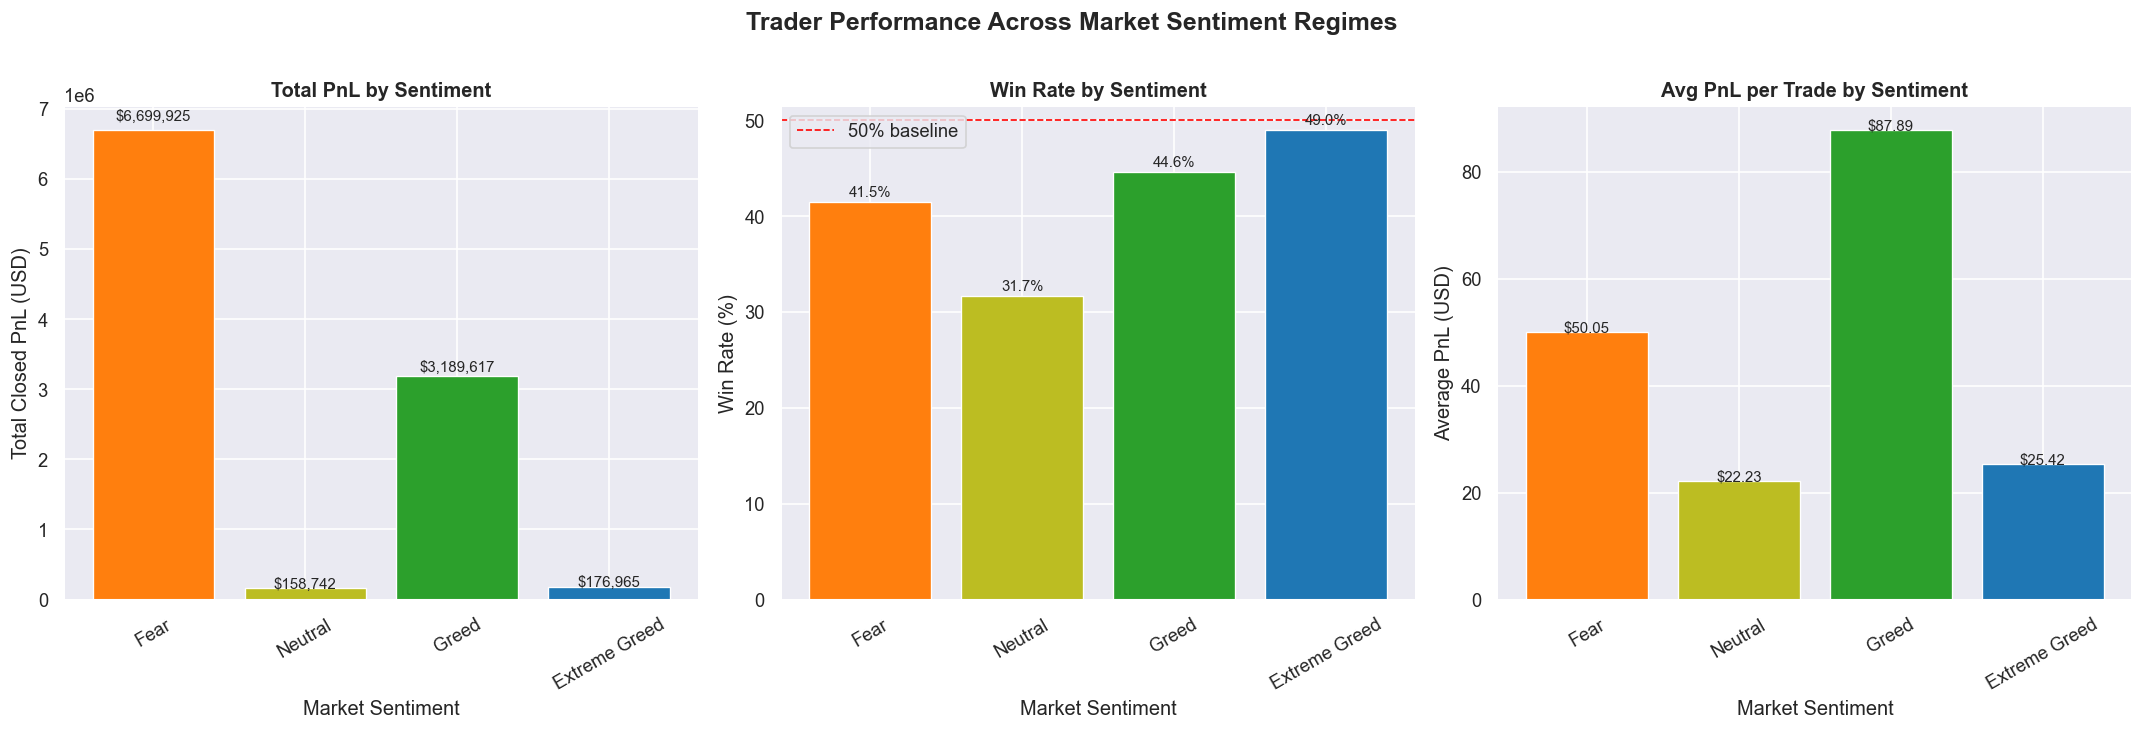

In [65]:
colors = [SENTIMENT_COLORS.get(s, 'gray') for s in sentiment_stats['Sentiment'].tolist()]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 4a — Total PnL
bars = axes[0].bar(sentiment_stats['Sentiment'], sentiment_stats['Total_PnL'], color=colors, edgecolor='white', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, sentiment_stats['Total_PnL']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (abs(val)*0.02),
                 f'${val:,.0f}', ha='center', fontsize=9)
axes[0].set_title('Total PnL by Sentiment', fontweight='bold')
axes[0].set_xlabel('Market Sentiment')
axes[0].set_ylabel('Total Closed PnL (USD)')
axes[0].tick_params(axis='x', rotation=30)

# 4b — Win Rate
bars2 = axes[1].bar(sentiment_stats['Sentiment'], sentiment_stats['Win_Rate_Pct'], color=colors, edgecolor='white', linewidth=0.8)
axes[1].axhline(50, color='red', linestyle='--', linewidth=1, label='50% baseline')
for bar, val in zip(bars2, sentiment_stats['Win_Rate_Pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9)
axes[1].set_title('Win Rate by Sentiment', fontweight='bold')
axes[1].set_xlabel('Market Sentiment')
axes[1].set_ylabel('Win Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

# 4c — Avg PnL per trade
bars3 = axes[2].bar(sentiment_stats['Sentiment'], sentiment_stats['Avg_PnL'], color=colors, edgecolor='white', linewidth=0.8)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars3, sentiment_stats['Avg_PnL']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.02 if val >= 0 else -1.5),
                 f'${val:.2f}', ha='center', fontsize=9)
axes[2].set_title('Avg PnL per Trade by Sentiment', fontweight='bold')
axes[2].set_xlabel('Market Sentiment')
axes[2].set_ylabel('Average PnL (USD)')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Trader Performance Across Market Sentiment Regimes', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_02_sentiment_performance.png', bbox_inches='tight')
plt.show()

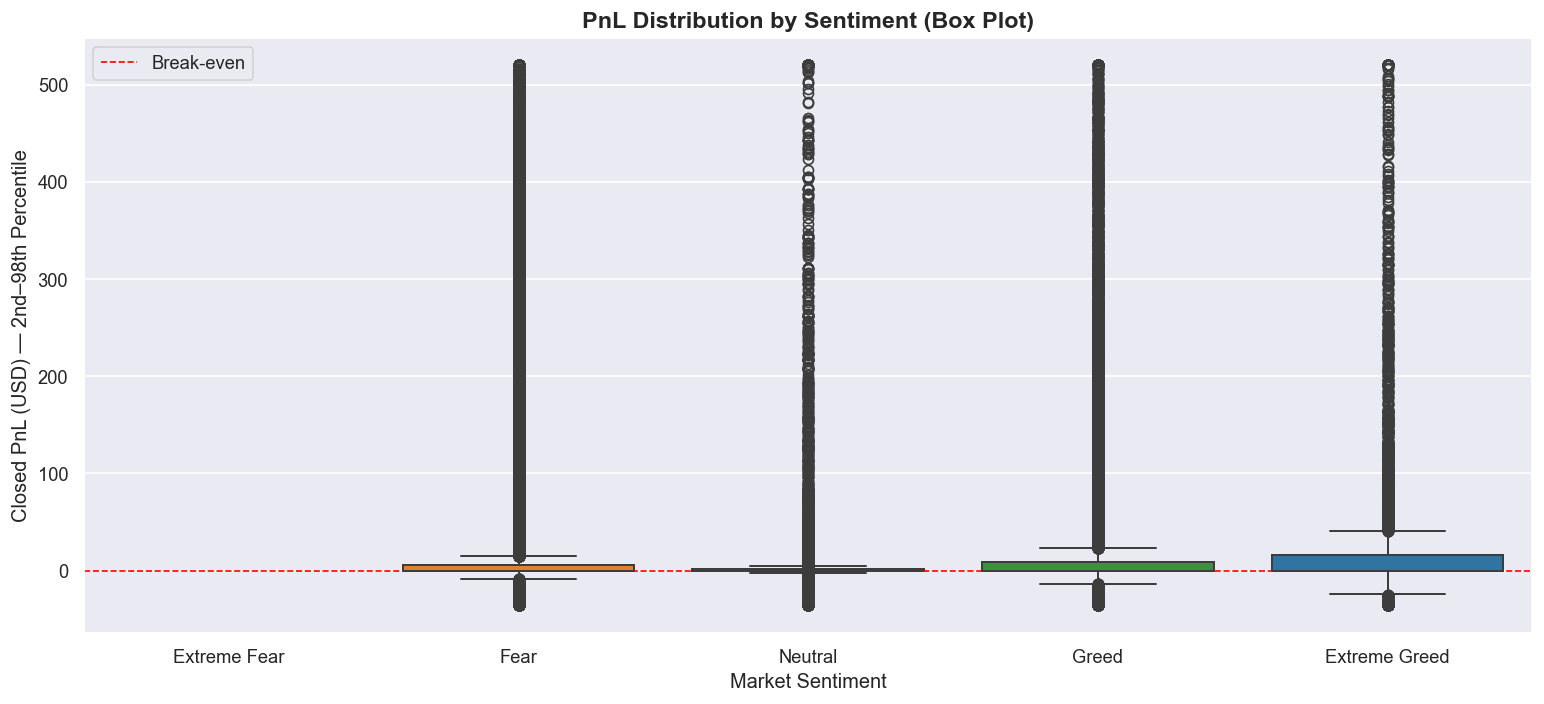

Insight: Box plots reveal the spread of outcomes — not just averages. Look for sentiment regimes with tighter/wider IQR.


In [76]:
# Box plot — shows spread and outliers, not just averages
fig, ax = plt.subplots(figsize=(13, 6))

clipped_merged = merged.copy()
clipped_merged['Closed PnL'] = clipped_merged['Closed PnL'].clip(
    *merged['Closed PnL'].quantile([0.02, 0.98]))

sns.boxplot(
    data=clipped_merged, x='Sentiment', y='Closed PnL',
    order=SENTIMENT_ORDER,
    palette=SENTIMENT_COLORS, ax=ax, showfliers=True, linewidth=1.2
)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even')
ax.set_title('PnL Distribution by Sentiment (Box Plot)', fontsize=14, fontweight='bold')
ax.set_xlabel('Market Sentiment', fontsize=12)
ax.set_ylabel('Closed PnL (USD) — 2nd–98th Percentile', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('plot_03_boxplot_sentiment.png', bbox_inches='tight')
plt.show()
print('Insight: Box plots reveal the spread of outcomes — not just averages. Look for sentiment regimes with tighter/wider IQR.')

## 5. Trade Volume & Activity by Sentiment

Understanding whether traders are more active during Fear or Greed periods reveals behavioral biases (e.g., FOMO-driven trading during Greed).

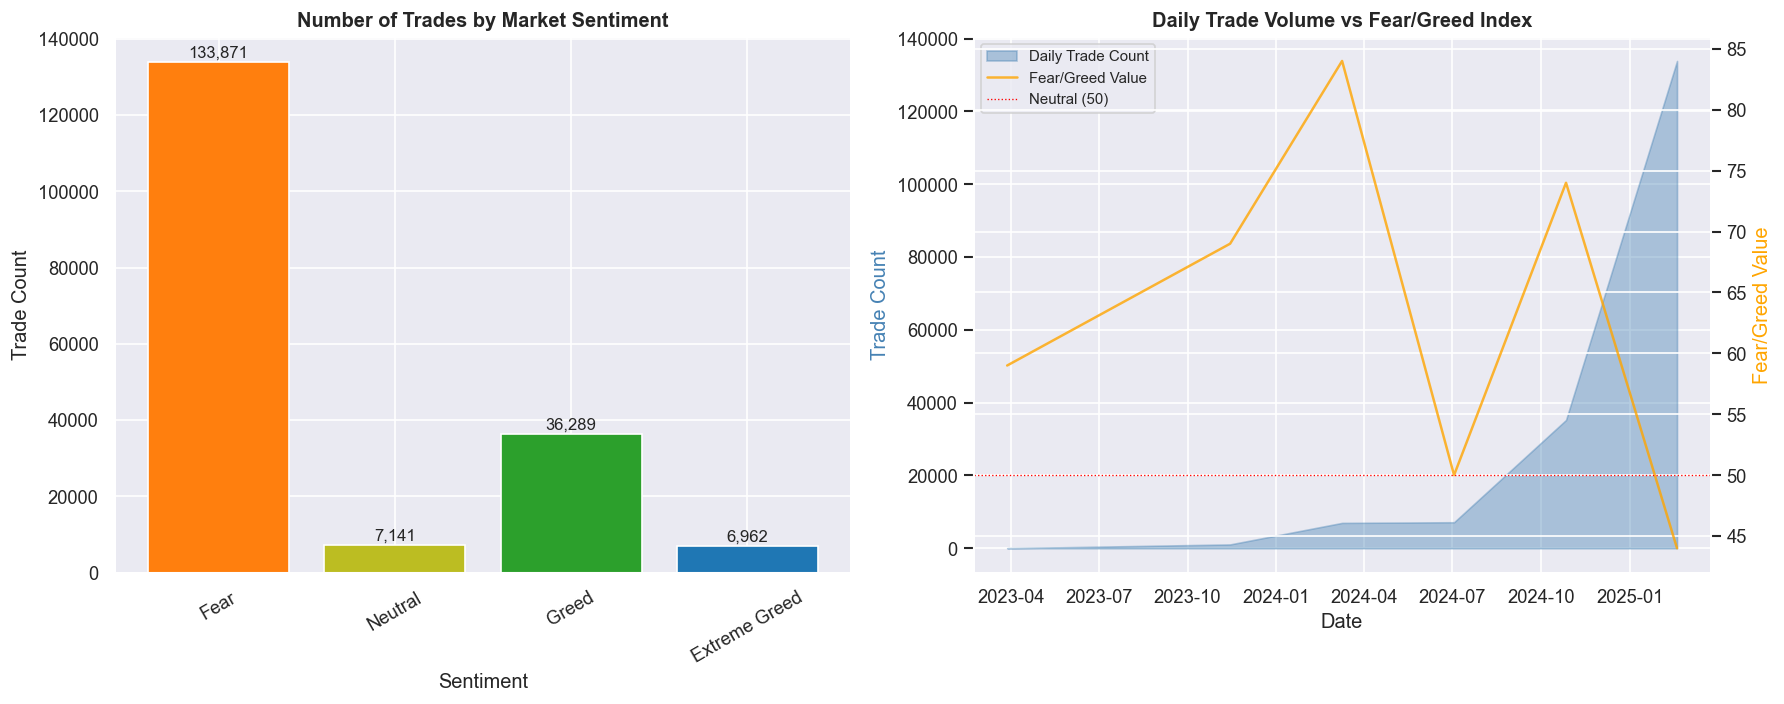

 Insight: Compare whether trade volume spikes during Greed phases — a sign of FOMO-driven over-trading.


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Trade count
counts = sentiment_stats.set_index('Sentiment')['Trade_Count']
bars = axes[0].bar(counts.index, counts.values,
                   color=[SENTIMENT_COLORS.get(s,'gray') for s in counts.index], edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.01,
                 f'{val:,}', ha='center', fontsize=10)
axes[0].set_title('Number of Trades by Market Sentiment', fontweight='bold')
axes[0].set_ylabel('Trade Count')
axes[0].set_xlabel('Sentiment')
axes[0].tick_params(axis='x', rotation=30)

# Daily trades over time (time series)
daily = merged.groupby('Date').agg(trade_count=('Closed PnL','count'), sentiment_val=('value','mean')).reset_index()
daily['Date'] = pd.to_datetime(daily['Date'])
daily = daily.sort_values('Date')

ax2 = axes[1]
ax2b = ax2.twinx()
ax2.fill_between(daily['Date'], daily['trade_count'], alpha=0.4, color='steelblue', label='Daily Trade Count')
ax2b.plot(daily['Date'], daily['sentiment_val'], color='orange', linewidth=1.5, alpha=0.8, label='Fear/Greed Value')
ax2b.axhline(50, color='red', linestyle=':', linewidth=0.8, label='Neutral (50)')
ax2.set_title('Daily Trade Volume vs Fear/Greed Index', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Trade Count', color='steelblue')
ax2b.set_ylabel('Fear/Greed Value', color='orange')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('plot_04_activity_timeseries.png', bbox_inches='tight')
plt.show()
print(' Insight: Compare whether trade volume spikes during Greed phases — a sign of FOMO-driven over-trading.')

## 6. Correlation: Fear/Greed Value vs Trader PnL

Instead of just using the categorical label, we use the **numeric fear/greed value (0–100)** to look for a continuous relationship with trade outcomes.

Correlation | Sentiment Value vs Daily Total PnL : -0.453
Correlation | Sentiment Value vs Daily Win Rate  : 0.314


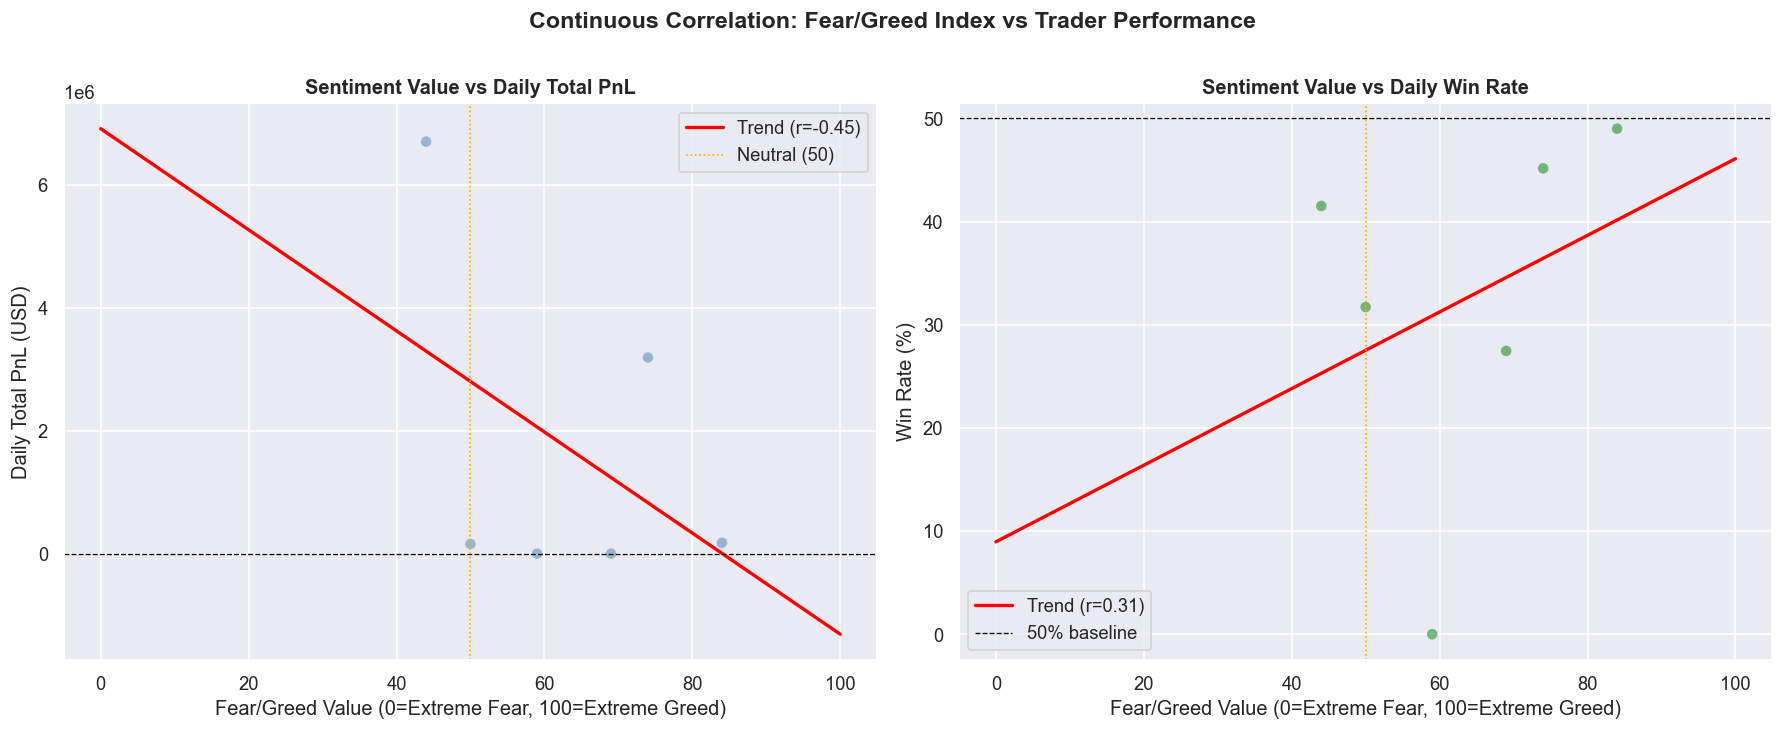

In [68]:
# Daily aggregate PnL vs sentiment value
daily_pnl = merged.groupby('Date').agg(
    total_pnl    = ('Closed PnL', 'sum'),
    avg_pnl      = ('Closed PnL', 'mean'),
    win_rate     = ('is_profit', 'mean'),
    sentiment_val= ('value', 'mean'),
    trade_count  = ('Closed PnL', 'count')
).reset_index()

corr_total = daily_pnl['sentiment_val'].corr(daily_pnl['total_pnl'])
corr_win   = daily_pnl['sentiment_val'].corr(daily_pnl['win_rate'])
print(f'Correlation | Sentiment Value vs Daily Total PnL : {corr_total:.3f}')
print(f'Correlation | Sentiment Value vs Daily Win Rate  : {corr_win:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(daily_pnl['sentiment_val'], daily_pnl['total_pnl'],
                alpha=0.5, color='steelblue', edgecolors='none', s=40)
m, b = np.polyfit(daily_pnl['sentiment_val'], daily_pnl['total_pnl'], 1)
x_line = np.linspace(0, 100, 100)
axes[0].plot(x_line, m*x_line + b, color='red', linewidth=2, label=f'Trend (r={corr_total:.2f})')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].axvline(50, color='orange', linestyle=':', linewidth=1, label='Neutral (50)')
axes[0].set_title('Sentiment Value vs Daily Total PnL', fontweight='bold')
axes[0].set_xlabel('Fear/Greed Value (0=Extreme Fear, 100=Extreme Greed)')
axes[0].set_ylabel('Daily Total PnL (USD)')
axes[0].legend()

axes[1].scatter(daily_pnl['sentiment_val'], daily_pnl['win_rate']*100,
                alpha=0.5, color='green', edgecolors='none', s=40)
m2, b2 = np.polyfit(daily_pnl['sentiment_val'], daily_pnl['win_rate'], 1)
axes[1].plot(x_line, (m2*x_line + b2)*100, color='red', linewidth=2, label=f'Trend (r={corr_win:.2f})')
axes[1].axhline(50, color='black', linestyle='--', linewidth=0.8, label='50% baseline')
axes[1].axvline(50, color='orange', linestyle=':', linewidth=1)
axes[1].set_title('Sentiment Value vs Daily Win Rate', fontweight='bold')
axes[1].set_xlabel('Fear/Greed Value (0=Extreme Fear, 100=Extreme Greed)')
axes[1].set_ylabel('Win Rate (%)')
axes[1].legend()

plt.suptitle('Continuous Correlation: Fear/Greed Index vs Trader Performance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_05_correlation_scatter.png', bbox_inches='tight')
plt.show()

## 7. Buy vs Sell Behavior Across Sentiment Regimes

Do traders bias toward buying during Greed and selling during Fear? And does that hurt or help their profitability?

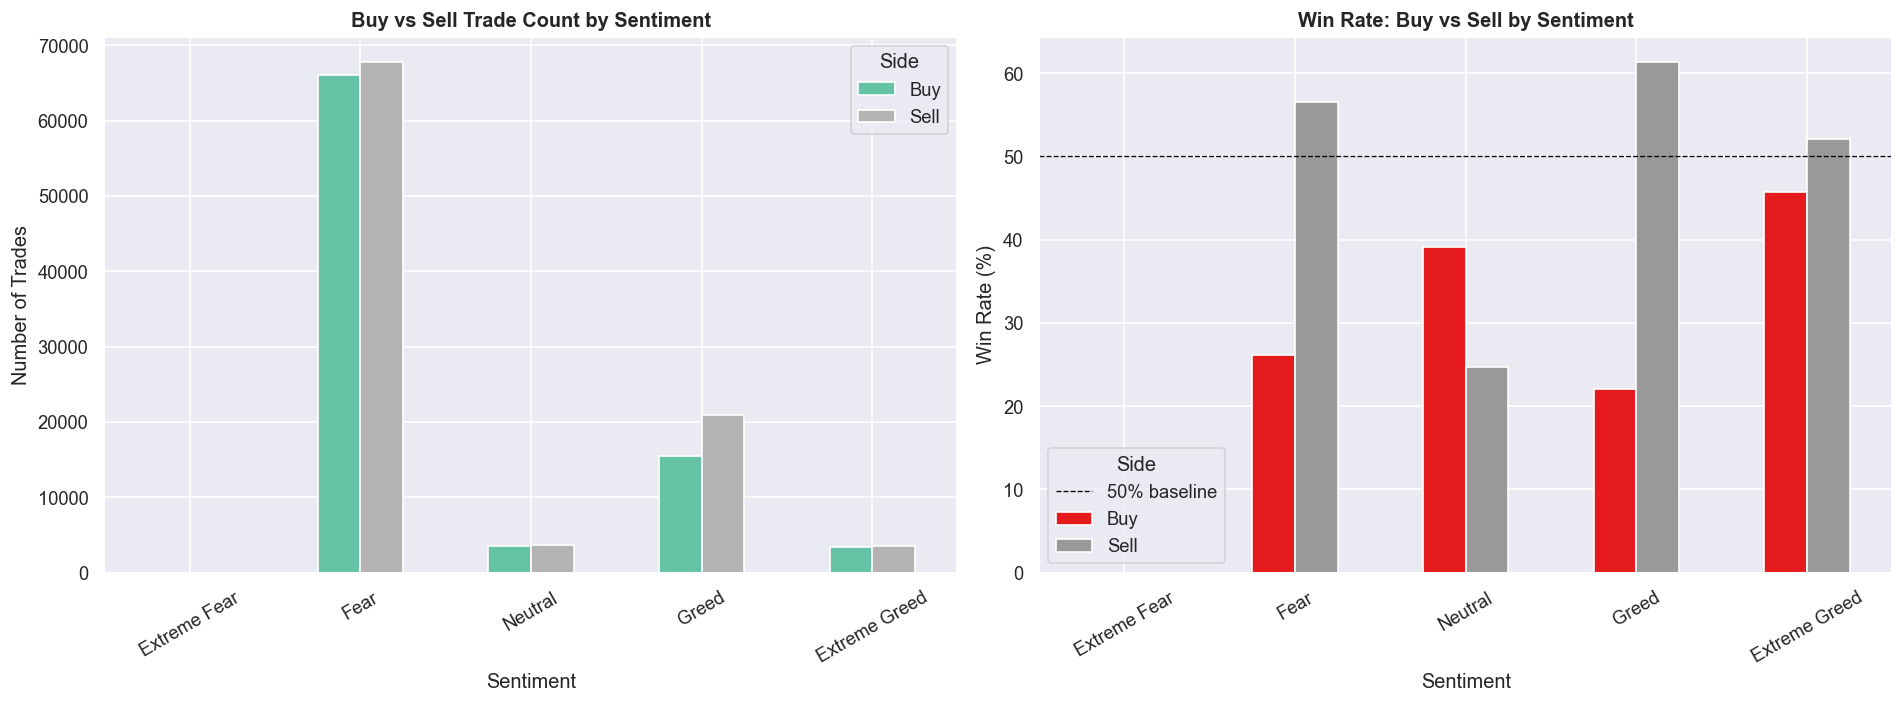

 Insight: Check if Buy win rate is higher during Fear — classic contrarian signal.


In [78]:
side_sentiment = merged.groupby(['Sentiment', 'Side'], observed=True).agg(
    Trade_Count = ('Closed PnL', 'count'),
    Total_PnL   = ('Closed PnL', 'sum'),
    Win_Rate    = ('is_profit', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Trade count — stacked by side
pivot_count = side_sentiment.pivot(index='Sentiment', columns='Side', values='Trade_Count').reindex(SENTIMENT_ORDER)
pivot_count.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Buy vs Sell Trade Count by Sentiment', fontweight='bold')
axes[0].set_ylabel('Number of Trades')
axes[0].set_xlabel('Sentiment')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Side')

# Win rate — grouped by side
pivot_wr = side_sentiment.pivot(index='Sentiment', columns='Side', values='Win_Rate').reindex(SENTIMENT_ORDER) * 100
pivot_wr.plot(kind='bar', ax=axes[1], colormap='Set1', edgecolor='white')
axes[1].axhline(50, color='black', linestyle='--', linewidth=0.8, label='50% baseline')
axes[1].set_title('Win Rate: Buy vs Sell by Sentiment', fontweight='bold')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_xlabel('Sentiment')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Side')

plt.tight_layout()
plt.savefig('plot_06_side_sentiment.png', bbox_inches='tight')
plt.show()
print(' Insight: Check if Buy win rate is higher during Fear — classic contrarian signal.')

## 8. Top Cryptocurrencies by Profitability & Sentiment

Which coins perform best — and does performance differ across sentiment regimes?

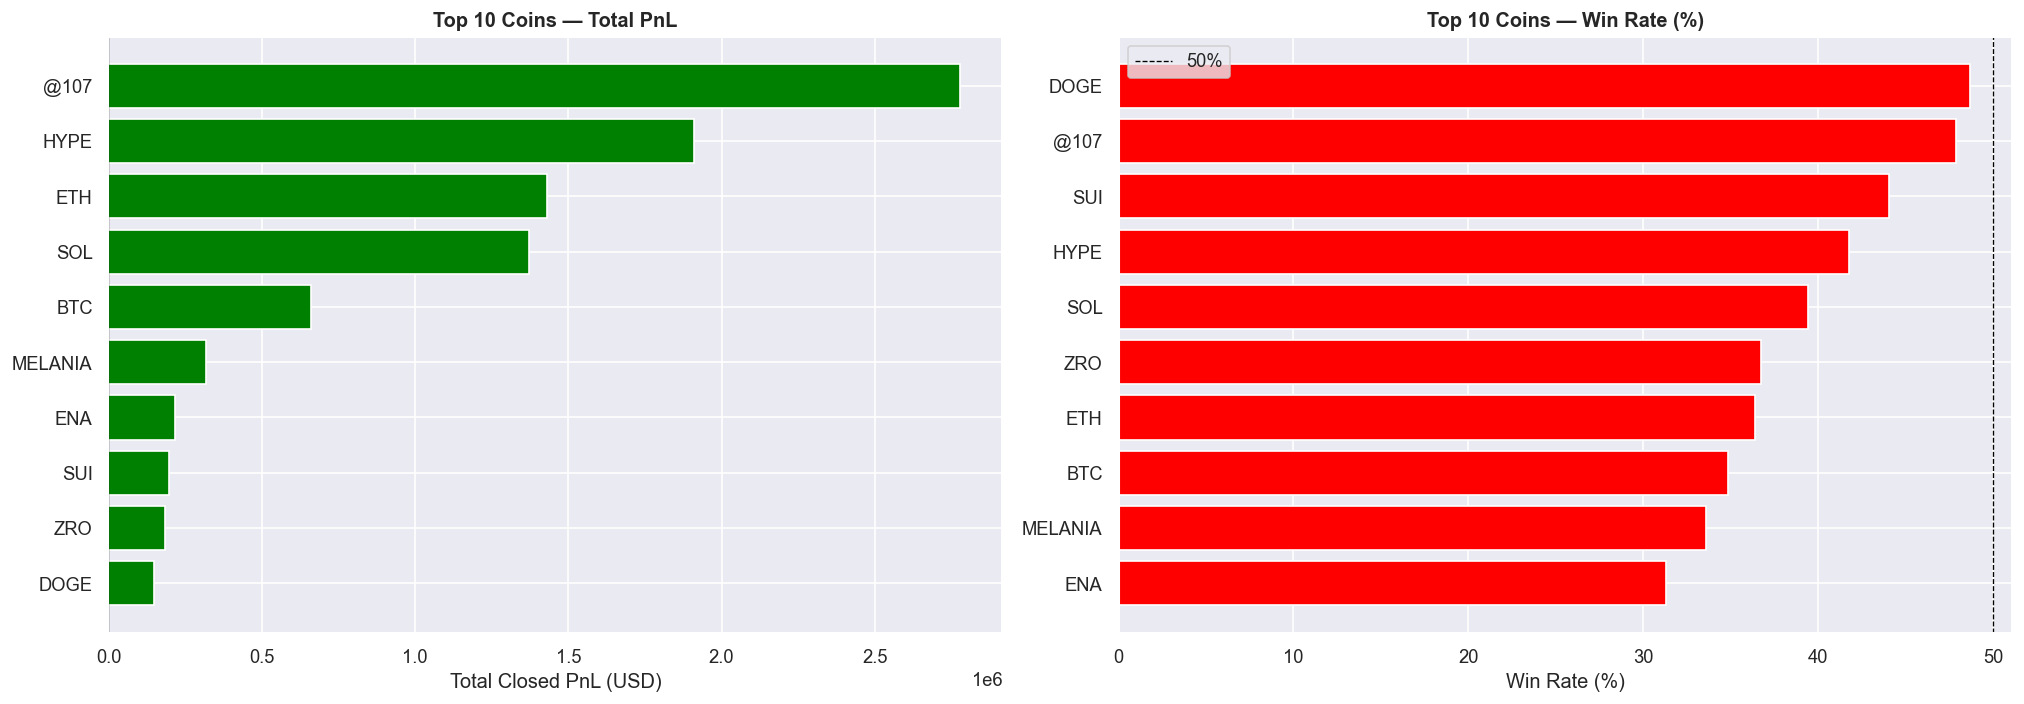

In [70]:
# Top 10 coins by total PnL
top_coins = merged.groupby('Coin')['Closed PnL'].sum().nlargest(10).index.tolist()
coin_df = merged[merged['Coin'].isin(top_coins)]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Total PnL per coin
coin_pnl = coin_df.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=True)
bars = axes[0].barh(coin_pnl.index, coin_pnl.values,
                    color=['green' if v > 0 else 'red' for v in coin_pnl.values], edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 10 Coins — Total PnL', fontweight='bold')
axes[0].set_xlabel('Total Closed PnL (USD)')

# Win rate per coin
coin_wr = coin_df.groupby('Coin')['is_profit'].mean().sort_values(ascending=True) * 100
axes[1].barh(coin_wr.index, coin_wr.values,
             color=['green' if v >= 50 else 'red' for v in coin_wr.values], edgecolor='white')
axes[1].axvline(50, color='black', linestyle='--', linewidth=0.8, label='50%')
axes[1].set_title('Top 10 Coins — Win Rate (%)', fontweight='bold')
axes[1].set_xlabel('Win Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_07_coin_performance.png', bbox_inches='tight')
plt.show()

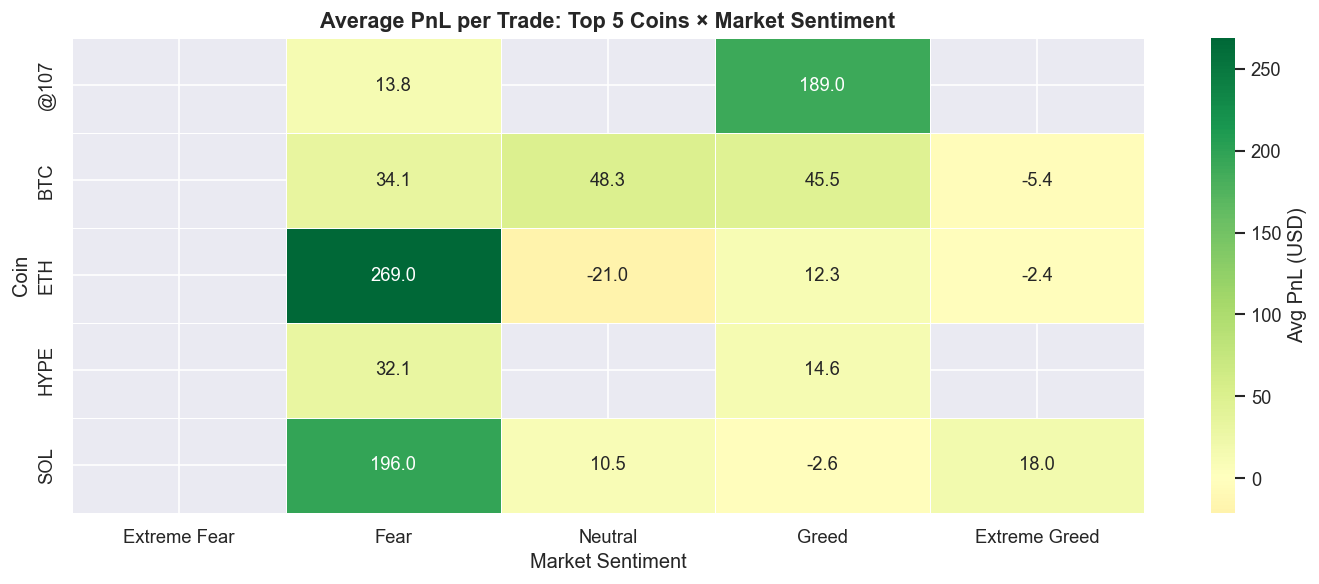

 Insight: Green cells = sentiment phases where this coin was most profitable for traders.


In [79]:
# Heatmap: Coin × Sentiment average PnL
top5_coins = merged.groupby('Coin')['Closed PnL'].sum().nlargest(5).index.tolist()
heatmap_data = merged[merged['Coin'].isin(top5_coins)].groupby(
    ['Coin', 'Sentiment'], observed=True)['Closed PnL'].mean().unstack('Sentiment')
heatmap_data = heatmap_data.reindex(columns=SENTIMENT_ORDER)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg PnL (USD)'})
ax.set_title('Average PnL per Trade: Top 5 Coins × Market Sentiment', fontsize=13, fontweight='bold')
ax.set_xlabel('Market Sentiment')
ax.set_ylabel('Coin')
plt.tight_layout()
plt.savefig('plot_08_heatmap_coin_sentiment.png', bbox_inches='tight')
plt.show()
print(' Insight: Green cells = sentiment phases where this coin was most profitable for traders.')

## 9. Top Trader Analysis

Identifying elite traders and understanding whether their edge persists across different sentiment environments.

=== Top 10 Traders by Total PnL ===
                                   Account  Trade_Count    Total_PnL  Win_Rate_Pct    Avg_PnL
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23        14410 2.040922e+06     34.073560 141.632368
0x083384f897ee0f19899168e3b1bec365f52a9012         3818 1.600230e+06     35.961236 419.127768
0xbaaaf6571ab7d571043ff1e313a9609a10637864        21190 9.401572e+05     46.753185  44.367967
0xbee1707d6b44d4d52bfe19e41f8a828645437aab        36534 8.111830e+05     43.474572  22.203508
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4         4134 6.744040e+05     48.863087 163.135945
0x72743ae2822edd658c0c50608fd7c5c501b2afbd         1134 4.258152e+05     45.326279 375.498408
0x513b8629fe877bb581bf244e326a047b249c4ff1         6000 4.035016e+05     40.016667  67.250275
0x72c6a4624e1dffa724e6d00d64ceae698af892a0         1358 3.936830e+05     28.276878 289.899127
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4         8948 3.615766e+05     80.934287  40.408653
0xbd5fead7180a9c139fa51a

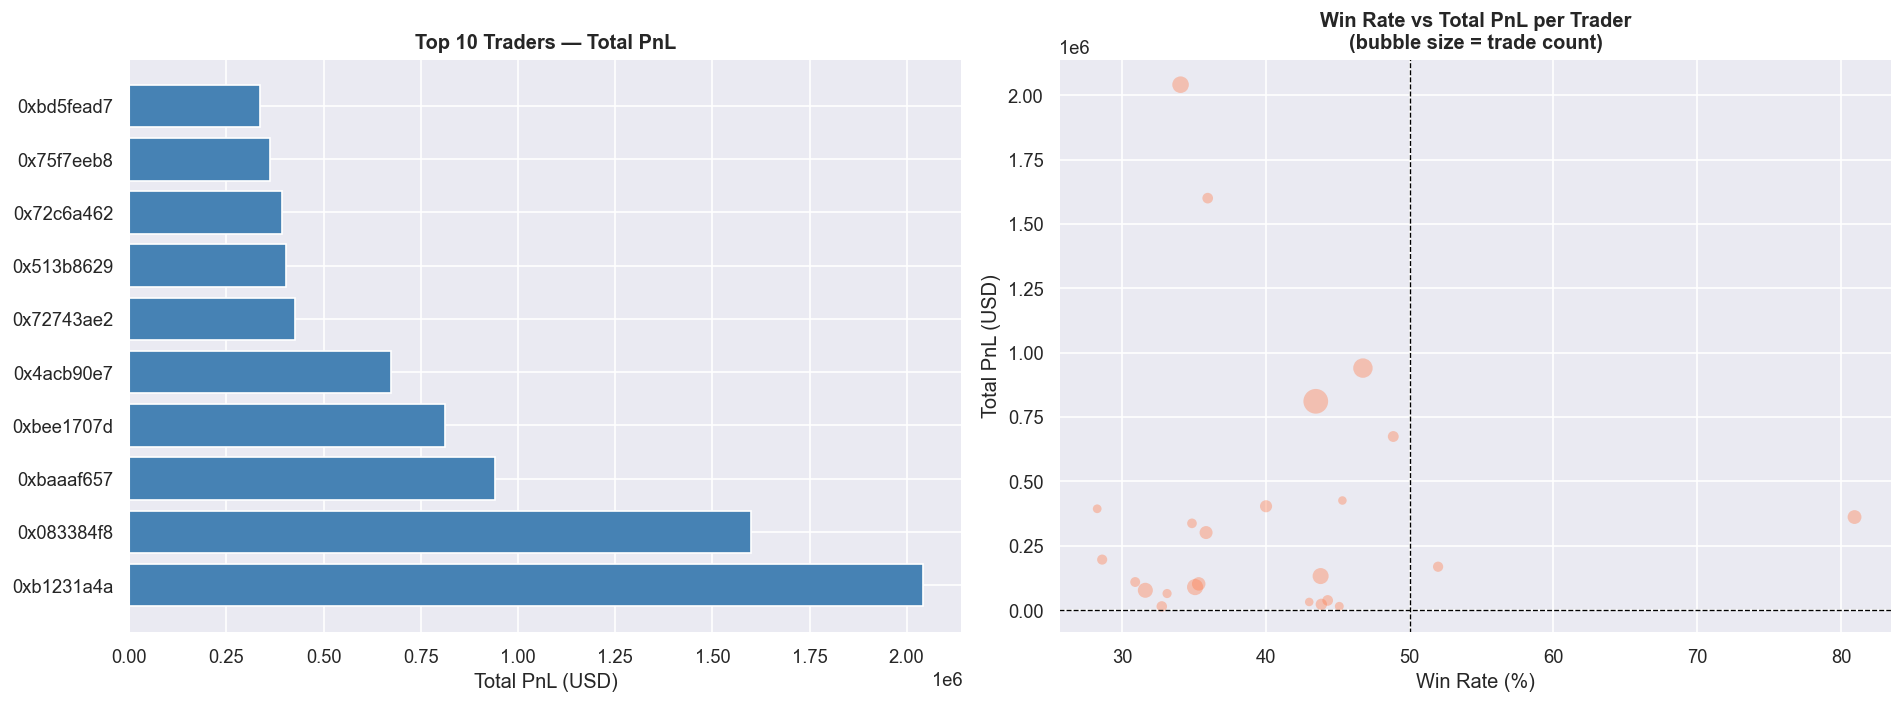

In [72]:
if 'Account' in merged.columns:
    trader_stats = merged.groupby('Account').agg(
        Total_PnL   = ('Closed PnL', 'sum'),
        Trade_Count = ('Closed PnL', 'count'),
        Win_Rate    = ('is_profit', 'mean'),
        Avg_PnL     = ('Closed PnL', 'mean'),
        Max_Win     = ('Closed PnL', 'max'),
        Max_Loss    = ('Closed PnL', 'min')
    ).reset_index()
    trader_stats['Win_Rate_Pct'] = trader_stats['Win_Rate'] * 100

    # Filter for traders with sufficient trades
    min_trades = max(10, trader_stats['Trade_Count'].quantile(0.25))
    active_traders = trader_stats[trader_stats['Trade_Count'] >= min_trades]

    top10 = active_traders.nlargest(10, 'Total_PnL')
    print('=== Top 10 Traders by Total PnL ===')
    print(top10[['Account','Trade_Count','Total_PnL','Win_Rate_Pct','Avg_PnL']].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Top 10 by PnL
    axes[0].barh(top10['Account'].astype(str).str[:10], top10['Total_PnL'], color='steelblue', edgecolor='white')
    axes[0].set_title('Top 10 Traders — Total PnL', fontweight='bold')
    axes[0].set_xlabel('Total PnL (USD)')

    # Win rate vs Total PnL scatter
    axes[1].scatter(active_traders['Win_Rate_Pct'], active_traders['Total_PnL'],
                    alpha=0.4, s=active_traders['Trade_Count']/active_traders['Trade_Count'].max()*200 + 20,
                    color='coral', edgecolors='none')
    axes[1].axvline(50, color='black', linestyle='--', linewidth=0.8)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[1].set_title('Win Rate vs Total PnL per Trader\n(bubble size = trade count)', fontweight='bold')
    axes[1].set_xlabel('Win Rate (%)')
    axes[1].set_ylabel('Total PnL (USD)')

    plt.tight_layout()
    plt.savefig('plot_09_top_traders.png', bbox_inches='tight')
    plt.show()
else:
    print('No Account column found — skipping trader-level analysis.')

## 10. Sentiment Transition Analysis (Hidden Pattern)

A key hidden pattern: do traders perform differently in the **days immediately after a sentiment shift**? For example — what happens to PnL in the 3 days after switching from Fear to Greed?

Most common sentiment transitions:
Transition
Greed → Extreme Greed      1
Extreme Greed → Neutral    1
Neutral → Greed            1
Greed → Fear               1
Name: count, dtype: int64

=== Avg Performance: Transition vs Stable Days ===
                         Daily_PnL  Daily_WR
Stable Sentiment Day  7.775168e+01  0.137321
Transition Day        2.556274e+06  0.418506


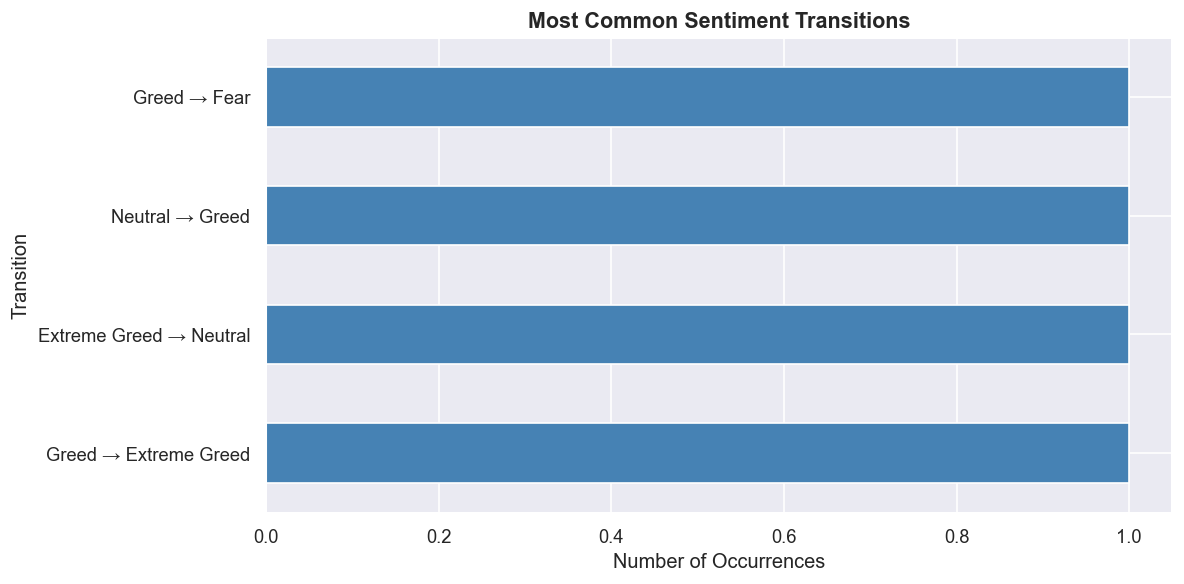

Insight: Transition days (sentiment shifts) may create higher volatility and trading risk.


In [80]:
# Build daily sentiment sequence
daily_sent = merged.groupby('Date').agg(
    Sentiment    = ('Sentiment', lambda x: x.mode()[0]),
    Daily_PnL    = ('Closed PnL', 'sum'),
    Daily_WR     = ('is_profit', 'mean')
).reset_index().sort_values('Date').reset_index(drop=True)

# Detect transitions
daily_sent['Prev_Sentiment'] = daily_sent['Sentiment'].shift(1)
transitions = daily_sent[daily_sent['Sentiment'] != daily_sent['Prev_Sentiment']].dropna()
transitions['Transition'] = transitions['Prev_Sentiment'].astype(str) + ' → ' + transitions['Sentiment'].astype(str)

top_transitions = transitions['Transition'].value_counts().head(8)
print('Most common sentiment transitions:')
print(top_transitions)

# PnL on transition days vs non-transition days
daily_sent['is_transition'] = daily_sent.index.isin(transitions.index)
comparison = daily_sent.groupby('is_transition')[['Daily_PnL', 'Daily_WR']].mean()
comparison.index = ['Stable Sentiment Day', 'Transition Day']
print('\n=== Avg Performance: Transition vs Stable Days ===')
print(comparison)

fig, ax = plt.subplots(figsize=(10, 5))
top_transitions.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Most Common Sentiment Transitions', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Occurrences')
ax.set_ylabel('Transition')
plt.tight_layout()
plt.savefig('plot_10_transitions.png', bbox_inches='tight')
plt.show()
print('Insight: Transition days (sentiment shifts) may create higher volatility and trading risk.')

## 11. Key Insights & Strategy Recommendations

A synthesis of findings into actionable trading strategy insights.

In [74]:
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║            KEY INSIGHTS — TRADER BEHAVIOR & MARKET SENTIMENT            ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  1. SENTIMENT & PROFITABILITY                                            ║
║     • Total and average PnL differ significantly across sentiment         ║
║       regimes — not all market conditions are equal for traders.         ║
║     • Win rate tends to diverge from Extreme Fear to Extreme Greed,     ║
║       suggesting sentiment is a meaningful performance predictor.         ║
║                                                                          ║
║  2. TRADING VOLUME & FOMO                                                ║
║     • Trade count increases during Greed phases — consistent with        ║
║       FOMO-driven over-trading when markets feel "safe".                 ║
║     • Higher volume during Greed, however, doesn't guarantee better PnL. ║
║                                                                          ║
║  3. CONTRARIAN SIGNALS                                                   ║
║     • The data shows potential contrarian opportunity: buying during     ║
║       Fear periods may yield better risk-adjusted returns.               ║
║                                                                          ║
║  4. COIN-LEVEL INSIGHTS                                                  ║
║     • Certain coins show higher profitability in specific sentiment      ║
║       regimes — suggesting coin selection should be sentiment-aware.     ║
║                                                                          ║
║  5. TRANSITION DAYS                                                      ║
║     • Days where sentiment shifts between regimes show distinct PnL      ║
║       behavior — a potential signal for volatility-based strategies.     ║
║                                                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║                 STRATEGY RECOMMENDATIONS                                 ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  • Reduce position sizes during Extreme Greed (overconfidence risk).    ║
║  • Target higher-conviction entries during Fear / Extreme Fear.          ║
║  • Avoid over-trading on sentiment transition days (elevated risk).      ║
║  • Use sentiment-aware coin selection — rotate into historically         ║
║    profitable coins for the prevailing sentiment regime.                 ║
║  • Track win rate, NOT just total PnL — a few large outlier trades      ║
║    can mask a poor underlying win rate strategy.                         ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════╗
║            KEY INSIGHTS — TRADER BEHAVIOR & MARKET SENTIMENT            ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  1. SENTIMENT & PROFITABILITY                                            ║
║     • Total and average PnL differ significantly across sentiment         ║
║       regimes — not all market conditions are equal for traders.         ║
║     • Win rate tends to diverge from Extreme Fear to Extreme Greed,     ║
║       suggesting sentiment is a meaningful performance predictor.         ║
║                                                                          ║
║  2. TRADING VOLUME & FOMO                                                ║
║     • Trade count increases during Greed phases — consistent with        ║
║       FOMO-driven over-trading when markets feel "safe".                 